In [2]:
"""
A simple example on how to use the CNN model on images larget than 50x50 pixels.
In short, you need to ensure proper normalization, see normalize_larger_image().
"""

import tensorflow as tf
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

# One should set the following environment variable if keras 3 is used:
# `export TF_USE_LEGACY_KERAS=1` into console.")
# Set paths to input and output

customs = {'Custom_mse_conv_func' : tf.keras.losses.mse, 'Custom_mae_conv_func' : tf.keras.losses.mae}
#Load Keras model.
model = tf.keras.models.load_model('model.h5', custom_objects = customs)


def gauss_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    Computes a 2D Gaussian function.

    Parameters:
        xy (tuple of ndarray): A tuple containing two 2D arrays (x, y) representing the grid coordinates.
        amplitude (float): The amplitude (peak value) of the Gaussian function.
        xo (float): The x-coordinate of the center of the Gaussian.
        yo (float): The y-coordinate of the center of the Gaussian.
        sigma_x (float): The standard deviation of the Gaussian in the x-direction.
        sigma_y (float): The standard deviation of the Gaussian in the y-direction.
        theta (float): The rotation angle of the Gaussian in radians.
        offset (float): The constant offset added to the Gaussian function.

    Returns:
        ndarray: A 1D array representing the raveled 2D Gaussian function values.
        It need to be reshaped to form a 2D array.
    """
    x, y = xy
    xo = float(xo)
    yo = float(yo)
    a = (np.cos(theta)**2)/(2*sigma_x**2) + (np.sin(theta)**2)/(2*sigma_y**2)
    b = -(np.sin(2*theta))/(4*sigma_x**2) + (np.sin(2*theta))/(4*sigma_y**2)
    c = (np.sin(theta)**2)/(2*sigma_x**2) + (np.cos(theta)**2)/(2*sigma_y**2)
    g = offset + amplitude*np.exp(- (a*((x-xo)**2) + 2*b*(x-xo)*(y-yo)
                                     + c*((y-yo)**2)))
    return g.ravel()


def generate_image(xyi, noise_mean, noise_std, psf_width, h, w):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img = np.random.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)
    ys = np.arange(h)
    xs = np.arange(w)
    xy = np.meshgrid(xs, ys)
    for x, y, intensity in xyi:
        img += gauss_2d(xy, intensity, x, y, psf_width,
                        psf_width, 0, 0).reshape((h, w))
    img = (img - np.min(img))
    img = img/np.sum(img)
    return img

def normalize_larger_image(img):
    h, w = img.shape
    img -= np.min(img)
    nimg = (img/np.sum(img))*(h*w/(50*50))
    return nimg

In [45]:
n_em = 30
noise_mean = 30
noise_std = 10
psf_width_px = 3
intensity = 20*noise_std
W = 256
xyi = np.random.random((n_em, 2))*W*0.9 + np.array(((W*0.05,W*0.05),))
xyi = np.hstack([xyi, np.ones((n_em,1))*intensity])
img = normalize_larger_image(generate_image(xyi, noise_mean, noise_std, psf_width_px, W, W))

images = img.reshape((1,*img.shape,1))
transformed_images = model.predict(images)

1/1 [==============================] - 2s 2s/step


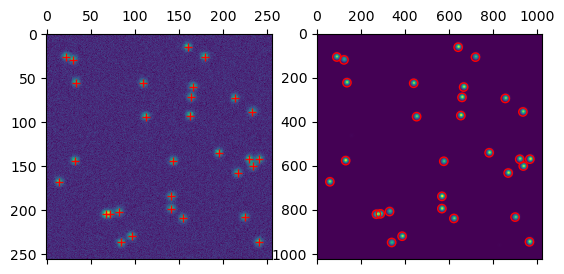

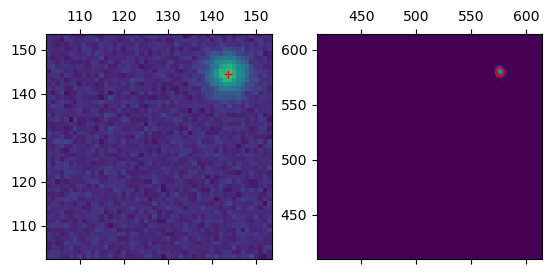

In [46]:
#plot results
fig, ax = plt.subplots(1,2)
ax[0].matshow(img)
ax[1].matshow(ndi.gaussian_filter(transformed_images[0,:,:,0],8))
ax[0].plot(xyi[:,0],xyi[:,1],'r+')
ax[1].scatter(xyi[:,0]*4+1.5,xyi[:,1]*4+1.5,facecolors='none', edgecolors='r')
plt.show()

#and plot zoom to central area
fig, ax = plt.subplots(1,2)
ax[0].matshow(img)
ax[1].matshow(ndi.gaussian_filter(transformed_images[0,:,:,0],2))
ax[0].plot(xyi[:,0],xyi[:,1],'r+')
ax[1].scatter(xyi[:,0]*4+1.5,xyi[:,1]*4+1.5,facecolors='none', edgecolors='r')
ax[0].set_xlim(img.shape[1]*0.4, img.shape[1]*0.6)
ax[0].set_ylim(img.shape[1]*0.4, img.shape[1]*0.6)
ax[1].set_xlim(transformed_images.shape[-2]*0.4, transformed_images.shape[-3]*0.6)
ax[1].set_ylim(transformed_images.shape[-2]*0.4, transformed_images.shape[-3]*0.6)
plt.show()